# Fine-Tuning Using Email Spam Classification

This experiment applies fine-tuning for a **binary text classification task** using the **SMS Spam Collection Dataset (2012) and Spam and Ham classification Balanced Dataset**, which both contains labeled *spam* and *ham* email/SMS messages. These datasets is used to adapt a pretrained language model to better distinguish between unwanted (spam) and legitimate (ham) messages.

During fine-tuning, the model learns task-specific patterns such as keyword usage, phrasing, and structural cues commonly found in spam messages. The objective is to improve classification accuracy by optimizing the model parameters on labeled examples from the dataset.

The results demonstrate that fine-tuning significantly enhances the model’s ability to correctly classify spam and ham messages, making it suitable for real-world email and message filtering applications.


In [1]:
import os
import ssl
import zipfile
import urllib.request
from pathlib import Path


import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np

import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import tiktoken
import torch.nn as nn

## load the dataset
**TWO Datasets and merge them together**

In [2]:
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download and extraction.")
        return

    # Create an unverified SSL context
    ssl_context = ssl._create_unverified_context()

    # Downloading the file
    with urllib.request.urlopen(url, context=ssl_context) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # Add .tsv file extension
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection\SMSSpamCollection.tsv already exists. Skipping download and extraction.


In [3]:
data_file_path2="spam_and_ham_classification.csv"
df1 = pd.read_csv(data_file_path, sep="\t", names=["Label", "Text"]) # first data set  
df2 = pd.read_csv(data_file_path2) # second data set 
df2 = df2.rename(columns={"text": "Text","label": "Label"})
print("the first dataset : \n" , df1.head())
print("------------------------------------------------")
print("the second dataset : \n" , df2.head())

the first dataset : 
   Label                                               Text
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
------------------------------------------------
the second dataset : 
   Label                                               Text
0   ham  into the kingdom of god and those that are ent...
1  spam  there was flow at hpl meter 1505 on april firs...
2   ham  take a look at this one campaign for bvyhprice...
3  spam  somu wrote actually thats what i was looking f...
4  spam  fathi boudra wrote i fixed the issue in the sv...


In [4]:
#CONATINATE BOTH IN ONE DATA SET 
df = pd.concat([df1, df2], ignore_index=True)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
15556,ham,this would be a great tragedy for all concerne...
15557,ham,"hello , welcome to medzonline filamentous shop..."
15558,ham,this is amazing stuff add some inches fast saf...
15559,spam,author jra date escapenumber escapenumber esca...


## DataSet EDA and preprocessing

In [5]:
print(df["Label"].value_counts())

Label
ham     10119
spam     5442
Name: count, dtype: int64


**as we can see that the data is not balanced its biased to ham emails** 

In [6]:
def create_balanced_dataset(df):
    
    # Count the instances of "spam"
    num_spam = df[df["Label"] == "spam"].shape[0]
    
    # Randomly sample "ham" instances to match the number of "spam" instances
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)
    
    # Combine ham "subset" with "spam"
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     5442
spam    5442
Name: count, dtype: int64


### some EDA TO SEE INFO ABOUT THE DATA

In [7]:
print(balanced_df['Text'].str.len().max())
print(balanced_df['Text'].str.len().min())
balanced_df['Text'].str.len().describe()

141261
2


count     10884.000000
mean       1233.946343
std        3157.644238
min           2.000000
25%         125.000000
50%         526.000000
75%        1346.250000
max      141261.000000
Name: Text, dtype: float64

**THERE IS A GRAT GAP BETWEEN BOTH the smallest messahe and the logest message**

(0.0, 14000.0)

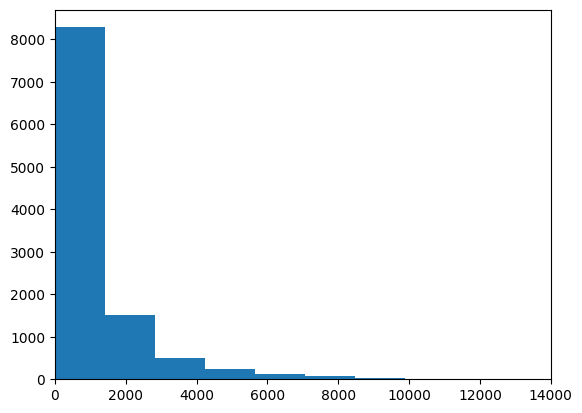

In [8]:
plt.hist(balanced_df['Text'].str.len(),bins=100)
plt.xlim(0, 14000)

**there is a great outliares in the data**

(0.0, 1500.0)

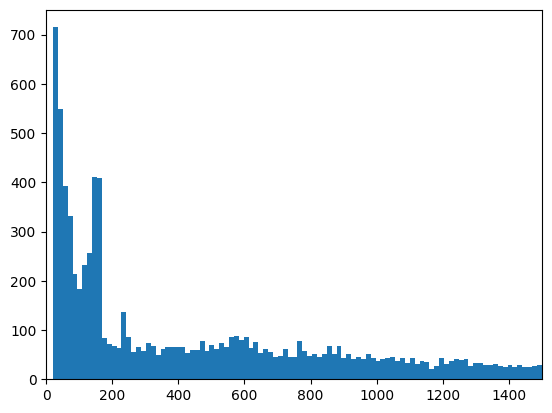

In [9]:
balanced_df = balanced_df[(balanced_df['Text'].str.len() < 1500) & (balanced_df['Text'].str.len() > 20) ]
plt.hist(balanced_df['Text'].str.len(),bins=100)
plt.xlim(0, 1500)

In [10]:
print(balanced_df["Label"].value_counts())

Label
ham     4668
spam    3669
Name: count, dtype: int64


In [11]:
#balance the data set again
balanced_df = create_balanced_dataset(balanced_df)
print(balanced_df["Label"].value_counts())

Label
ham     3669
spam    3669
Name: count, dtype: int64


**we convert the "string" class labels "ham" and "spam" into integer class labels 0 and 1, respectively:**

In [12]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

**We create a random_split function to split the dataset into three parts: 70% for training, 10% for validation, and 20% for testing.**

In [13]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder


In [14]:
#CHECK tat the fucnction work well
print(len(train_df))
print(len(validation_df))
print(len(test_df))

5136
733
1469


**Additionally, we save the dataset as CSV (comma-separated value) files, which we can reuse later:**

In [15]:
train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

## CREATING DATALOADERS

**In the case of email spam classification, have two primary options:**

- (1) Truncate all messages to the length of the shortest message in the dataset or batch.

- (2) Pad all messages to the length of the longest message in the dataset or batch.


-------------
**option 1 is computationally cheaper, but it may result in significant information loss if shorter messages are much smaller than the average or longest messages, potentiallyreducing model performance.**

`So, we opt for the second option, which preserves the entirecontent of all messages.`

**To implement option 2, where all messages are padded to the length of the longest message in the dataset, we add padding tokens to all shorter messages.** 

- For this purpose,we use "<|endoftext|>" as a padding token

    
- However, instead of appending the string "<|endoftext|>" to each of the text messages
directly, we can add the token ID corresponding to "<|endoftext|>" to the encoded text


## DataSet
**For this purpose, we define the SpamDataset class.**

- `This SpamDataset class handles several key tasks: it identifies the longest sequence in the training dataset, encodes the text messages, and ensures that all other sequences are padded with a padding token to match the length of the longest sequence.`
  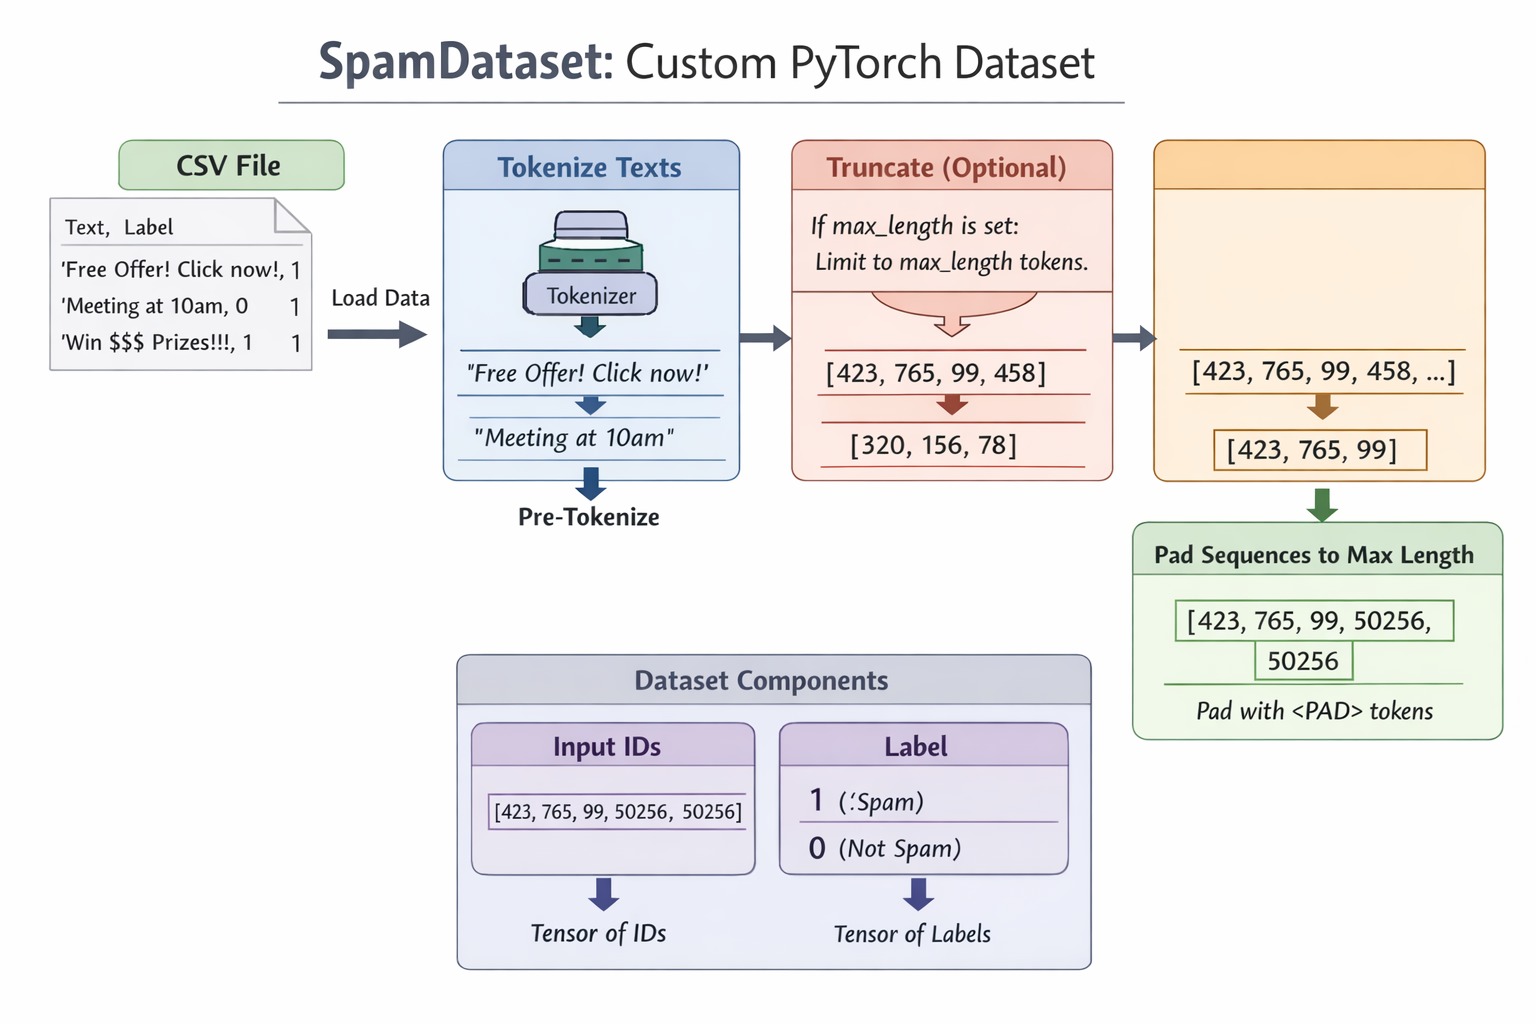

In [16]:
class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

In [17]:
# test the class and put max length because he max length is very high aroud 2000 token 
tokenizer = tiktoken.get_encoding("gpt2")
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=256, 
    tokenizer=tokenizer
)

print(train_dataset.max_length)

256


**Next, we pad the validation and test sets to match the length of the longest training sequence.**

- It's important to note that any validation and test set samples exceeding the length of the longest training example are truncated using encoded_text[:self.max_length] in the SpamDataset code we defined earlier.

In [18]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

## DataLoader
**Using the datasets as inputs, we can instantiate the data loaders similarly to what we did earlier in training llm.**

- However, in this case, the targets represent class labels rather than the next tokens in the text.

- For instance, choosing a batch size of 8, each batch will consist of 8 training examples of length of max length and the corresponding class label of each example.

In [19]:
num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

**To ensure that the data loaders are working and are indeed returning batches of the expected size, we iterate over the training loader and then print the tensor dimensions of the last batch:**

In [20]:
print("Train loader:")
for input_batch, target_batch in train_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 256])
Label batch dimensions torch.Size([8])


**to get an idea of the dataset size, let's print the total number of batches in each dataset:**

In [21]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

642 training batches
92 validation batches
184 test batches


## INITIALIZING A MODEL WITH PRETRAINED WEIGHTS
**In this section, we prepare the model we will use for the classification-finetuning to identify spam messages.**

- **We start with initializing the pretrained model we worked with in the previous parts**

**THE first part and the most important is the `MULTIHEADATTENTION`**

In [22]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_in,d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"
       # intial values 
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        # intialize the weight matrices 
        self.W_K = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_Q = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_V = nn.Linear(d_in, d_out, bias=qkv_bias)

        # to applay the mask of causal attention
        self.register_buffer("mask",torch.triu(torch.ones(context_length, context_length),diagonal=1))
        # to applay dropout 
        self.dropout = nn.Dropout(dropout)

        # this is like a mixer to mix the weights from the heads together 
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
    def forward(self,x):
        b, num_tokens, d_in = x.shape

        keys = self.W_K(x) # Shape: (batch, num_tokens, d_out)
        queries = self.W_Q(x)
        values = self.W_V(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        # calculate the attention weights 
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        # dropout to enhance training 
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim) >> to get d_out 
        context_vec = (attn_weights @ values).transpose(1, 2) 

        # Combine heads, where self.d_out = self.num_heads * self.head_dim >> final context vector for each word 
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        # the mixer will mex the result of each head with other to consider all relations that each head collect
        context_vec = self.out_proj(context_vec) 


        return context_vec

**THEN THE MISRTY BOX `TransformerBlock`**

In [23]:
# layer normalization part 
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim)) 
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True) # calculate the mean for each row 
        var = x.var(dim=-1, keepdim=True, unbiased=False) #calulate the variance of each row , unbiased=False >> for calc  population  devide by n 
        norm_x = (x - mean) / torch.sqrt(var + self.eps) #The variable eps is added to the variance to prevent division by zero during normalization
        return self.scale * norm_x + self.shift 

# the GELU activation function block 
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))
        ))
        
# feed forward part
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), #layer1 >input 768 dim and output 4*768 like gpt2
            GELU(), #the activation function between them 
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), #layer1 >input 4*768 dim and output 768 like gpt2
        )

    def forward(self, x):
        return self.layers(x)
# transformers part        
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            # cfg in the first line of the page the gpt-2 parameters
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], 
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])
        self.ff = FeedForward(cfg) # the feed forward after attention 
        self.norm1 = LayerNorm(cfg["emb_dim"])# normalization before attention 
        self.norm2 = LayerNorm(cfg["emb_dim"]) # normalization after feed forward  

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x # >> the inputs 
        x = self.norm1(x) #1 the normalization layer 
        # multi head attention 
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size] 
        x = self.drop_shortcut(x) #the dropout 
        x = x + shortcut  # Add the original input back x = data_after_attention + input embedings

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

### GPT Model the big box and main father

In [24]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

**THESE FUNCTIONS WHICH WILL ASSIGN THE trained weights of gpt_2 from OPENAI TO OUR MODEL INTIAL RANDOM WEIGHTS**

In [25]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right, dtype=left.dtype, device=left.device))

def load_weights_into_gpt(gpt, params):
    # assign the weights of the postional emmbedings 
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    # assign the weights of the token emmbedings 
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    ## assign the weights of the transformer block  
    for b in range(len(params["blocks"])):
        # assing the weights of Q,K,V OF THE ATTENTION  
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_Q.weight = assign(
            gpt.trf_blocks[b].att.W_Q.weight, q_w.T)
        gpt.trf_blocks[b].att.W_K.weight = assign(
            gpt.trf_blocks[b].att.W_K.weight, k_w.T)
        gpt.trf_blocks[b].att.W_V.weight = assign(
            gpt.trf_blocks[b].att.W_V.weight, v_w.T)
        
         # assing the biases of Q,K,V OF THE ATTENTION 
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_Q.bias = assign(
            gpt.trf_blocks[b].att.W_Q.bias, q_b)
        gpt.trf_blocks[b].att.W_K.bias = assign(
            gpt.trf_blocks[b].att.W_K.bias, k_b)
        gpt.trf_blocks[b].att.W_V.bias = assign(
            gpt.trf_blocks[b].att.W_V.bias, v_b)

        # assing the weights and the biases of Output Projection (Attention Output)
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

          # assing the weights and the biases of FFD NN OF THE ATTENTION 
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

          # assing the weights and the biases LAYER NORM1 OF THE ATTENTION 
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        # assing the weights and the biases LAYER NORM2 OF THE ATTENTION 
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])
              # assing the weights and the biases FINAL LAYER  
        gpt.out_head.weight = gpt.tok_emb.weight
  # assing the weights and the biases FINAL LAYER NORM 
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
  # assing the weights and the biases FINAL  NORM SHIFT 
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])


In [26]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

#make sure that our tokens in the training not greater than 1024
assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"Dataset length {train_dataset.max_length} exceeds model's context "
    f"length {BASE_CONFIG['context_length']}. Reinitialize data sets with "
    f"`max_length={BASE_CONFIG['context_length']}`"
)

**load the pretrained weights as we did before**

In [27]:
#from the file that have the functions that will download the parameters to our model 
from GPT_downloader import download_and_load_gpt2

In [28]:
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")

settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

Error downloading the file: HTTPSConnectionPool(host='openaipublic.blob.core.windows.net', port=443): Max retries exceeded with url: /gpt-2/models%5C124M%5Ccheckpoint (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x00000276D7895A00>: Failed to resolve 'openaipublic.blob.core.windows.net' ([Errno 11001] getaddrinfo failed)"))
Please check the URL: https://openaipublic.blob.core.windows.net/gpt-2/models\124M\checkpoint
Error downloading the file: HTTPSConnectionPool(host='openaipublic.blob.core.windows.net', port=443): Max retries exceeded with url: /gpt-2/models%5C124M%5Cencoder.json (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x00000276D7B3B5C0>: Failed to resolve 'openaipublic.blob.core.windows.net' ([Errno 11001] getaddrinfo failed)"))
Please check the URL: https://openaipublic.blob.core.windows.net/gpt-2/models\124M\encoder.json
Error downloading the file: HTTPSConnectionPool(host='openaipublic.blob.core.windows.net',

**To ensure that the model was loaded correctly, let's double-check that it generates coherent text**

In [29]:
#use the gpt model to genrate text 
def generate_text_simple(model, idx, max_new_tokens, context_size):
    # idx is (batch, n_tokens) array of indices in the current context
    for _ in range(max_new_tokens):
        
        # Crop current context if it exceeds the supported context size
        # E.g., if LLM supports only 5 tokens, and the context size is 10
        # then only the last 5 tokens are used as context
        idx_cond = idx[:, -context_size:]
        
        # Get the predictions
        with torch.no_grad():
            logits = model(idx_cond)
        
        # Focus only on the last time step
        # (batch, n_tokens, vocab_size) becomes (batch, vocab_size)
        #logits = logits[all_batches, last raw, all columns ] 
        logits = logits[:, -1, :]  

        # Apply softmax to get probabilities
        probas = torch.softmax(logits, dim=-1)  # (batch, vocab_size)

        # Get the idx of the vocab entry with the highest probability value
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)  # (batch, 1)

        # Append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch, n_tokens+1)

    return idx
# use tiktoken to genrate tokens     
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor
#use tiktoken lib to create text from token ids 
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())
#text example 
start_context = "Every effort moves you"
#tokenizer 
tokenizer = tiktoken.get_encoding("gpt2")

**To ensure that the model was loaded correctly, let's double-check that it generates coherent text**

In [30]:
text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


**Now, before we start finetuning the model as a spam classifier, let's see if the model can perhaps already classify spam messages by by prompting it with instructions:**

In [31]:
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=30,
    context_size=BASE_CONFIG["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive


**Based on the output, it's apparent that the model struggles with following instructions.**

- **This is anticipated, as it has undergone only pretraining and lacks instruction-finetuning**

## ADDING A CLASSIFICATION HEAD

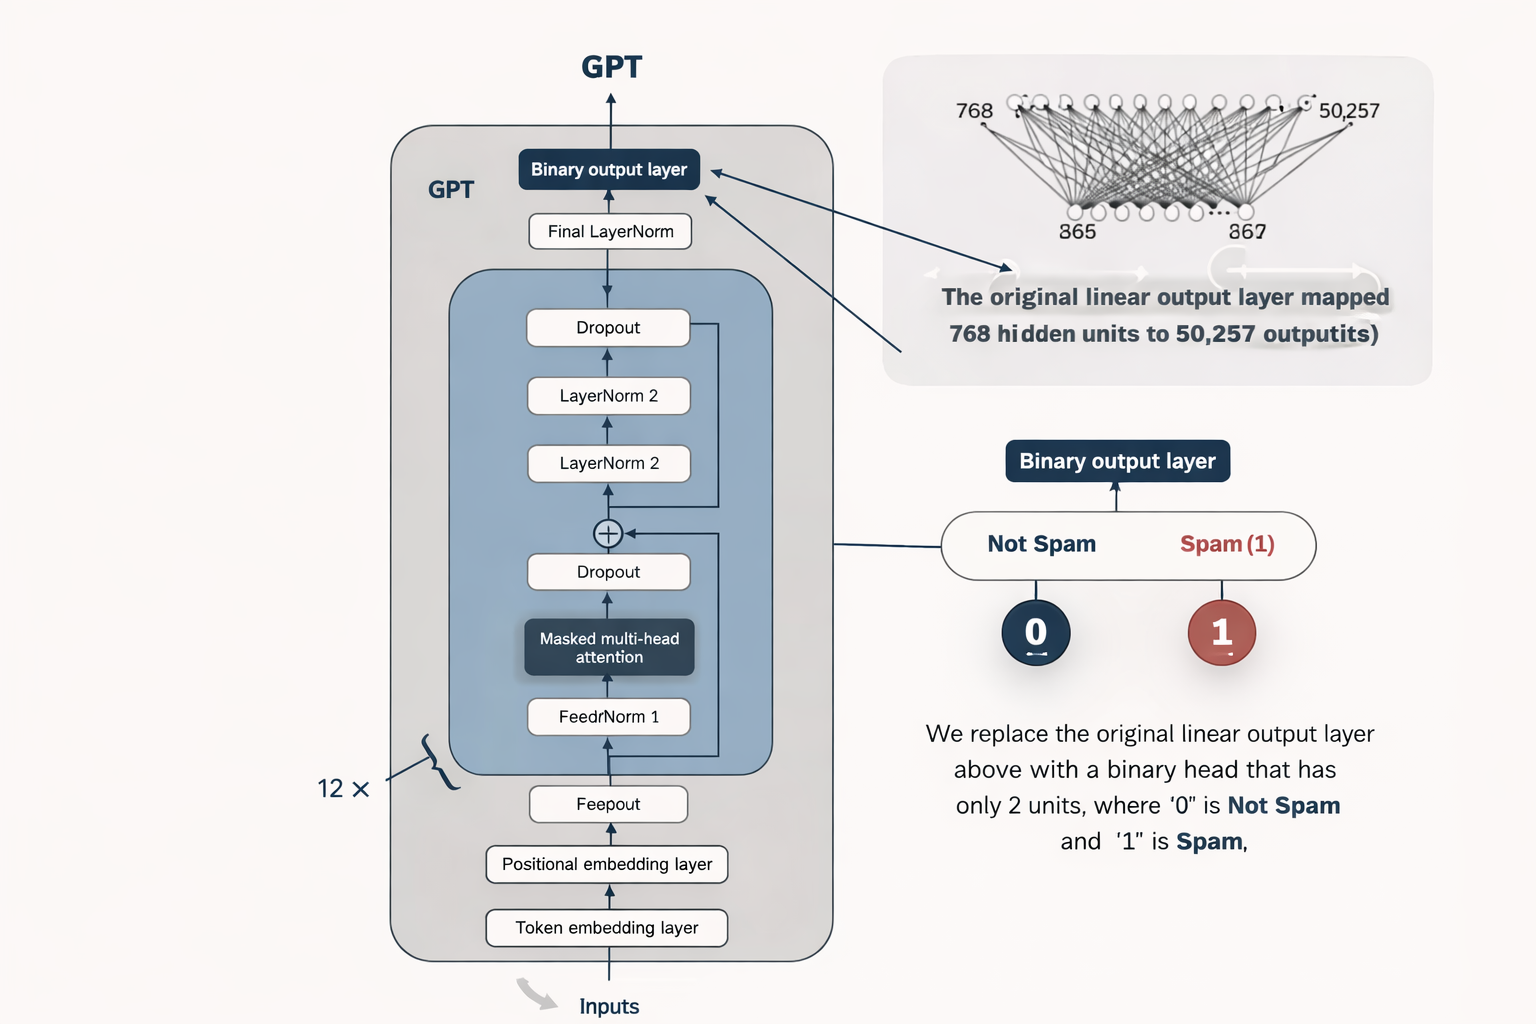

**we modify the pretrained large language model to prepare it for classification-finetuning.**

- To do this :-
`we replace the original output layer, which maps the hidden representation to a vocabulary of 50,257, with a smaller output layer that maps to two classes: 0 ("not spam") and 1 ("spam")`

**lets se the model we have now**
-  the GPTModel consists of embedding layers followed by 12 identical transformer blocks (only the last block is shown for brevity), followed by a final LayerNorm and the output layer, out_head.

In [32]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_K): Linear(in_features=768, out_features=768, bias=True)
        (W_Q): Linear(in_features=768, out_features=768, bias=True)
        (W_V): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
      )
      (drop_shortcut): Dropout(p=0.0, inplace=False)
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_K): Linear(in_features=768, out_featur

**we will finetune**
- To get the model ready for classification-finetuning, we first freeze the model, meaning that we make all layers non-trainable
- Then, we replace the output layer (model.out_head), which originally maps the layer inputs to 50,257 dimensions (the size of the vocabulary)

In [33]:
for param in model.parameters():
    param.requires_grad = False

In [34]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

**for finetune this model**
- we will only update the last 3 neural netorks because the early layers trained on large data sets that can perform many tasks
- 1- `This new model.out_head output layer`.
- 2- `last transformer block`.
- 3- `the final LayerNorm module`.
  
**`its requires_grad attribute set to True to be trainable`**

In [35]:
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True

**now lets try the new model with the new output layer**

In [36]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])


In [37]:
#Then, we can pass the encoded token IDs to the model as usual:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)


Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


**we are interested in finetuning this model so that it returns a class label that indicates whether a model input is spam or not spam.**

- To achieve this, we don't need to finetune all 4 output rows but can focus on a single output token.

- In particular, we will focus on the last row corresponding to the last output token

In [38]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


## CALCULATING THE CLASSIFICATION LOSS AND ACCURACY

**Before we proceed with the finetuning itself**
- only one small part remains: implementing the model evaluation functions used during finetuning.
- let's briefly discuss how we convert the model outputs into class label predictions.

Let's consider the last token output from the previous section:

In [39]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


In [40]:
# We can obtain the class label via the following code:
probas = torch.softmax(outputs[:, -1, :], dim=-1) # optional 
label = torch.argmax(probas)
print("Class label:", label.item()) # classfied as spam 

Class label: 1


In [41]:
# we can simplify the code as follows, without using softmax:
logits = outputs[:, -1, :]
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


**This concept can be used to compute the so-called classification accuracy**
- which measures the percentage of correct predictions across a dataset.

To determine the classification accuracy,we apply the argmax-based prediction code to all examples in the dataset and calculate the proportion of correct predictions by defining a calc_accuracy_loader function.

In [42]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

**Let's use the function to determine the classification accuracies across various datasets estimated from 10 batches for efficiency:**

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the training data loader

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 48.75%
Validation accuracy: 52.50%
Test accuracy: 43.75%


**To improve the prediction accuracies, we need to finetune the model.**

**Classification accuracy is not a differentiable function, so we use cross entropy loss as a proxy to maximize accuracy.**
- This is the same cross entropy loss discussed earlier.

In [44]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

**We use the calc_loss_batch function to compute the loss for a single batch obtained from the previously defined data loaders. To calculate the loss for all batches in a data loader, we define the calc_loss_loader function**

In [45]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

**Similar to calculating the training accuracy, we now compute the initial loss for each data set:**

In [46]:
with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 2.544
Validation loss: 3.131
Test loss: 3.364


## FINETUNING THE MODEL ON SUPERVISED DATA

**we define and use the training function to finetune the pretrained LLM and improve its spam classification accuracy.**
- The training loop is the same overall training loop we used earlier, with the only difference being that we calculate the classification accuracy instead of generating a sample text for evaluating the model.

> Step 1: Set model to training mode

> Step 2: Reset loss gradients from previous batch iteration

> Step 3: Calculate loss gradients

> Step 4: Update model weights using loss gradients

> Step 5: track examples instead of tokens

> Step 6: Optional evaluation step

>Step 7: Calculate accuracy after each epoch



In [47]:
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(                          # this function intalized in the next section 
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

**the evaluate_model function used in the train_classifier_simple**

In [48]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

**Next, we initialize the optimizer, set the number of training epochs, and initiate the training using the train_classifier_simple function.**

In [49]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=300, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 1.956, Val loss 2.928
Ep 1 (Step 000300): Train loss 0.504, Val loss 0.750
Ep 1 (Step 000600): Train loss 0.557, Val loss 0.576
Training accuracy: 77.50% | Validation accuracy: 67.50%
Ep 2 (Step 000900): Train loss 0.523, Val loss 0.541
Ep 2 (Step 001200): Train loss 0.177, Val loss 0.498
Training accuracy: 87.50% | Validation accuracy: 77.50%
Ep 3 (Step 001500): Train loss 0.179, Val loss 0.481
Ep 3 (Step 001800): Train loss 0.084, Val loss 0.501
Training accuracy: 97.50% | Validation accuracy: 87.50%
Ep 4 (Step 002100): Train loss 0.186, Val loss 0.433
Ep 4 (Step 002400): Train loss 0.217, Val loss 0.393
Training accuracy: 95.00% | Validation accuracy: 90.00%
Ep 5 (Step 002700): Train loss 0.048, Val loss 0.332
Ep 5 (Step 003000): Train loss 0.051, Val loss 0.361
Training accuracy: 95.00% | Validation accuracy: 90.00%
Training completed in 72.32 minutes.


**We then use matplotlib to plot the loss function for the training and validation set:**

In [50]:
def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

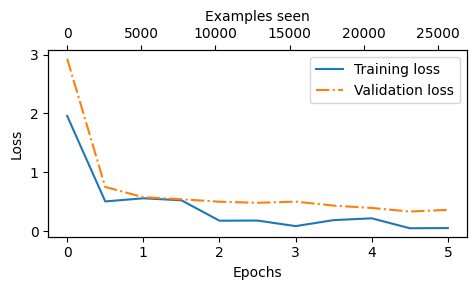

In [51]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

**As we can see based on the sharp downward slope, the model is learning well from the training data, and there is little to no indication of overfitting;**

**Using the same plot_values function, let's now also plot the classification accuracies:**

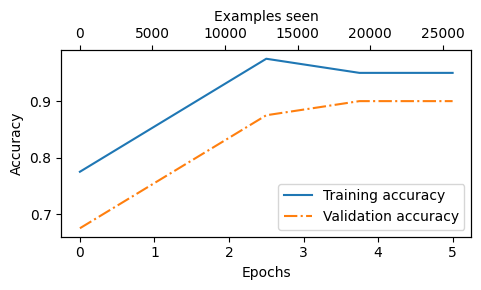

In [52]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

**Now, we will calculate the performance metrics for the training, validation, and test sets across the entire dataset by running the following code, this time without defining the eval_iter value:**

In [53]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 95.64%
Validation accuracy: 93.18%
Test accuracy: 93.53%


## 📊 Spam Classification Results

- **Train Accuracy:** 95.64%
- **Validation Accuracy:** 93.18%
- **Test Accuracy:** 93.53%

### ✅ Summary
The model performs well with consistent results across training, validation, and test data.  
There is no significant overfitting, and the model generalizes well.

### 🧠 Conclusion
The model is reliable and suitable for spam detection.

## USING THE LLM AS A SPAM CLASSIFIER

**Finally, let's use the finetuned GPT-based spam classification model.**
> Step 1: Prepare inputs to the model

> Step 2: Truncate sequences if they too long

> Step 3: Pad sequences to the longest sequence

> Step 4: Add batch dimension

> Step 5: Model inference without gradient tracking

> Step 6: Logits of the last output token

> Step 7: Return the classified result


In [54]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0] #1024 >> max model can see 


    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]

    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()

    # Return the classified result
    return "spam" if predicted_label == 1 else "not spam"

**Let's try this classify_review function on an example text:**

In [55]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(
    text_1, model, tokenizer, device, max_length=train_dataset.max_length
))

spam


In [56]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

not spam


**Finally, let's save the model in case we want to reuse the model later without having to train it again using the torch.save method**

In [57]:
torch.save(model.state_dict(), "spam_classifier.pth")

**Once saved, the model can be loaded as follows:**

In [59]:
model_state_dict = torch.load("spam_classifier.pth")
model.load_state_dict(model_state_dict)

<All keys matched successfully>

In [60]:
#save full model not just the weights 
torch.save(model, "full_model.pth")